# Phần 2: Phân tích phân phối xác suất của Diamonds
**Người thực hiện:** Thái Hà  
**Dữ liệu:** `data/processed/cleaned_diamonds.csv` do nhóm bàn giao; nguồn gốc [Diamonds trên Kaggle](https://www.kaggle.com/datasets/shivam2503/diamonds).  
**Mức ý nghĩa:** 5%. **Hai biến phân tích:** `price` và `carat`.

Notebook kiểm tra đầu vào, mô tả phân phối, ước lượng ba ứng viên **normal, lognormal, exponential**, vẽ đồ thị và kiểm định độ phù hợp. Mọi số liệu và nhận xét định lượng phía dưới được tính khi chạy notebook; không lấy số liệu của tập dữ liệu thô thay cho tập sạch.

**Nguyên tắc:** đọc dữ liệu chung, giữ nguyên mọi quan sát và ngoại lai hợp lệ, chỉ xuất sản phẩm vào `figures/part2_distribution/`. Không thực hiện lại bước làm sạch của phần 1.

**Cách chạy:** chọn kernel `.venv` (Python 3.12) rồi **Restart Kernel → Run All**. Có thể chạy từ thư mục gốc repo hoặc `notebooks/`. Bước bootstrap dùng toàn bộ dữ liệu và có thể cần khoảng một phút tùy máy.

## 2.1. Vì sao chọn `price` và `carat`?

| Biến | Ý nghĩa, đơn vị | Lý do chọn |
| :--- | :--- | :--- |
| `price` | Giá kim cương, USD | Đại diện giá trị kinh tế; phân phối giúp biết phần lớn viên có mức giá nào và nhóm giá cao làm thay đổi trung bình ra sao. |
| `carat` | Khối lượng, carat | Thuộc tính vật lý quan trọng khi mô tả kim cương; phân phối cho biết mẫu tập trung ở nhóm khối lượng nào và mức độ hiếm của viên lớn. |

Hai biến là đại lượng đo, không phải số lần xảy ra sự kiện trong một khoảng. Vì vậy **không chọn Poisson**, kể cả khi `price` được ghi bằng số nguyên USD. Normal là mô hình đối xứng để đối chiếu; lognormal phù hợp về miền dương và là ứng viên cho dữ liệu lệch phải; exponential là mô hình dương, giảm dần với đuôi phải để kiểm tra thêm. Đây là **ứng viên cần kiểm chứng**, không phải kết luận có sẵn.

Phân tích dưới đây là **phân phối biên** của từng biến. Không dùng nó để kết luận quan hệ nhân quả giữa khối lượng và giá; ảnh hưởng của `cut`, `color`, `clarity` thuộc những phân tích khác của nhóm.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import importlib.metadata
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

# Các hằng số tập trung ở đây để dễ giải thích và tái lập kết quả.
ALPHA = 0.05
SEED = 42
N_BOOTSTRAP = 1999
BOOTSTRAP_BATCH = 32  # Chia lô để tránh tạo ma trận mô phỏng quá lớn trong RAM.
VARIABLES = ['price', 'carat']
UNITS = {'price': 'USD', 'carat': 'carat'}
MODEL_ORDER = ['normal', 'lognormal', 'exponential']
MODEL_LABELS = {'normal': 'Normal', 'lognormal': 'Lognormal', 'exponential': 'Exponential'}
MODEL_COLORS = {'normal': '#c62828', 'lognormal': '#2e7d32', 'exponential': '#6a1b9a'}

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'data' / 'processed' / 'cleaned_diamonds.csv').is_file() else cwd.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_diamonds.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'part2_distribution'
if not DATA_PATH.is_file():
    raise FileNotFoundError(f'Không tìm thấy {DATA_PATH}. Hãy chạy từ gốc repo hoặc notebooks/.')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = pd.read_csv(DATA_PATH)
df_original = df.copy(deep=True)  # Dùng để xác nhận cuối notebook không thay đổi dữ liệu.
saved_files = []

sns.set_theme(style='whitegrid', font='DejaVu Sans', font_scale=1.05)
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

print(f'Python đang chạy: {sys.executable}')
print(f'Dữ liệu đầu vào: {DATA_PATH}')
print(f'Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'SHA-256: {source_sha256}')
display(df.head())

Python đang chạy: D:\STUDY\TQHDL-CK\Diamonds-analysis\.venv\Scripts\python.exe
Dữ liệu đầu vào: D:\STUDY\TQHDL-CK\Diamonds-analysis\data\processed\cleaned_diamonds.csv
Kích thước: 53,772 dòng × 10 cột
SHA-256: 356dd4512d6a2a8c9b62c4b200983daa4c03048401d0991b9778f9ac4cae8237


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.230000,Ideal,E,SI2,61.500000,55.000000,326,3.950000,3.980000,2.430000
1,0.210000,Premium,E,SI1,59.800000,61.000000,326,3.890000,3.840000,2.310000
2,0.230000,Good,E,VS1,56.900000,65.000000,327,4.050000,4.070000,2.310000
3,0.290000,Premium,I,VS2,62.400000,58.000000,334,4.200000,4.230000,2.630000
4,0.310000,Good,J,SI2,63.300000,58.000000,335,4.340000,4.350000,2.750000


## 2.2. Kiểm tra đầu vào và giữ nguyên ngoại lai

Trước khi tính toán, kiểm tra các cột cần dùng, kiểu số, giá trị thiếu, vô hạn và miền dương. Lognormal cần giá trị **lớn hơn 0** để lấy logarithm. Notebook dừng với thông báo rõ nếu đầu vào không hợp lệ, thay vì âm thầm bỏ dòng hoặc thay thế giá trị.

Dòng trùng được báo cáo nhưng không tự xóa. Quy tắc IQR ở mục sau chỉ **đánh dấu** quan sát nằm ngoài khoảng $[Q_1-1.5IQR, Q_3+1.5IQR]$. Một viên kim cương lớn hoặc đắt có thể hoàn toàn hợp lệ; không loại nó chỉ vì vượt ngưỡng thống kê.

In [2]:
required_columns = {'price', 'carat', 'x', 'y', 'z'}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f'Thiếu cột bắt buộc: {sorted(missing_columns)}')
if df.empty:
    raise ValueError('Dữ liệu rỗng; không thể phân tích phân phối.')
non_numeric = [column for column in required_columns if not pd.api.types.is_numeric_dtype(df[column])]
if non_numeric:
    raise TypeError(f'Các cột phải có kiểu số: {non_numeric}')

validation = pd.DataFrame([
    {'Kiểm tra': 'Số dòng', 'Giá trị': len(df)},
    {'Kiểm tra': 'Số cột', 'Giá trị': df.shape[1]},
    {'Kiểm tra': 'Giá trị thiếu trong toàn bộ dữ liệu', 'Giá trị': int(df.isna().sum().sum())},
    {'Kiểm tra': 'Dòng trùng hoàn toàn (chỉ báo cáo)', 'Giá trị': int(df.duplicated().sum())},
    {'Kiểm tra': 'NaN hoặc vô hạn trong price/carat', 'Giá trị': int((~np.isfinite(df[VARIABLES].to_numpy(dtype=float))).sum())},
    {'Kiểm tra': 'Giá trị price/carat <= 0', 'Giá trị': int((df[VARIABLES] <= 0).sum().sum())},
    {'Kiểm tra': 'Dòng có kích thước x/y/z <= 0', 'Giá trị': int((df[['x', 'y', 'z']] <= 0).any(axis=1).sum())},
])
display(validation)

if df.isna().any().any():
    raise ValueError('Tập sạch vẫn có giá trị thiếu; cần đối chiếu với phần 1, không tự làm sạch lại.')
if not np.isfinite(df[list(required_columns)].to_numpy(dtype=float)).all():
    raise ValueError('Đầu vào có giá trị không hữu hạn.')
if (df[VARIABLES] <= 0).any().any() or (df[['x', 'y', 'z']] <= 0).any().any():
    raise ValueError('Giá, khối lượng và kích thước vật lý cần lớn hơn 0.')
if (df[VARIABLES].nunique() < 2).any():
    raise ValueError('Biến cần có ít nhất hai giá trị phân biệt để ước lượng phân phối.')

def export_csv(table, filename, index=False):
    """Chỉ lưu bảng kết quả trong thư mục sản phẩm của phần 2."""
    target = FIGURES_DIR / filename
    table.to_csv(target, index=index, encoding='utf-8-sig')
    saved_files.append(target)

export_csv(validation, 'input_validation.csv')
print('Đầu vào đạt yêu cầu. Không loại bỏ hoặc thay đổi bất kỳ quan sát nào.')

,Kiểm tra,Giá trị
0,Số dòng,53772
1,Số cột,10
2,Giá trị thiếu trong toàn bộ dữ liệu,0
3,Dòng trùng hoàn toàn (chỉ báo cáo),0
4,NaN hoặc vô hạn trong price/carat,0
5,Giá trị price/carat <= 0,0
6,Dòng có kích thước x/y/z <= 0,0


Đầu vào đạt yêu cầu. Không loại bỏ hoặc thay đổi bất kỳ quan sát nào.


### Các thống kê dùng để đọc phân phối

- **Mean và median:** mean lớn hơn median thường đi cùng lệch phải, cần đối chiếu thêm biểu đồ và skewness.
- **Độ lệch chuẩn, phương sai, CV:** đo độ phân tán; $CV=s/\bar{x}\times100\%$ giúp so sánh hai biến khác đơn vị. Độ lệch chuẩn và phương sai dùng `ddof=1`.
- **Q1, Q3, IQR, P95, P99, min/max:** mô tả vùng trung tâm và đuôi mà không xóa quan sát.
- **Skewness:** dương là lệch phải, âm là lệch trái. **Excess kurtosis** lấy chuẩn làm mốc 0; dương thường phản ánh đuôi nặng hơn chuẩn, nhưng không đủ để nhận dạng một họ phân phối.
- **Số giá trị phân biệt và tần số lặp:** giúp nhận biết làm tròn hoặc tập trung tại các mốc khối lượng. Tỷ lệ IQR chỉ mô tả quan sát vượt ngưỡng, không đồng nghĩa dữ liệu sai.

In [3]:
summary_rows = []
for variable in VARIABLES:
    x = df[variable]
    q1, median, q3 = x.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = (x < lower) | (x > upper)
    summary_rows.append({
        'Biến': variable, 'Đơn vị': UNITS[variable], 'n': len(x),
        'Số giá trị phân biệt': x.nunique(), 'Mean': x.mean(), 'Median': median,
        'SD (ddof=1)': x.std(ddof=1), 'Variance (ddof=1)': x.var(ddof=1),
        'CV (%)': 100 * x.std(ddof=1) / x.mean(),
        'Min': x.min(), 'Q1': q1, 'Q3': q3, 'P95': x.quantile(0.95),
        'P99': x.quantile(0.99), 'Max': x.max(), 'IQR': iqr,
        'Skewness': x.skew(), 'Excess kurtosis': x.kurt(),
        'Ngưỡng IQR dưới': lower, 'Ngưỡng IQR trên': upper,
        'Số quan sát ngoài IQR': int(flagged.sum()), 'Tỷ lệ ngoài IQR (%)': 100 * flagged.mean(),
    })
summary = pd.DataFrame(summary_rows).set_index('Biến')
display(summary.T)
export_csv(summary, 'descriptive_statistics.csv', index=True)

for variable in VARIABLES:
    counts = df[variable].value_counts().head(8)
    top_values = counts.rename('Số quan sát').to_frame()
    top_values['Tỷ lệ (%)'] = 100 * counts / len(df)
    print(f'8 giá trị {variable} xuất hiện nhiều nhất (đơn vị: {UNITS[variable]}):')
    display(top_values)

price_integer_pct = 100 * np.isclose(df['price'], np.round(df['price']), rtol=0, atol=1e-9).mean()
carat_cent_pct = 100 * np.isclose(df['carat'] * 100, np.round(df['carat'] * 100), rtol=0, atol=1e-9).mean()
print(f'Price ghi theo USD nguyên: {price_integer_pct:.2f}% quan sát.')
print(f'Carat nằm trên lưới 0,01 carat: {carat_cent_pct:.2f}% quan sát.')
print('Các giá trị lặp do cách ghi nhận được giữ nguyên trong mọi phép tính.')

Biến,price,carat
Đơn vị,USD,carat
n,53772,53772
Số giá trị phân biệt,11597,273
Mean,"3,931.137321",0.797525
Median,"2,401.000000",0.700000
SD (ddof=1),"3,985.853004",0.473150
Variance (ddof=1),"15,887,024.165666",0.223871
CV (%),101.391854,59.327376
Min,326.000000,0.200000
Q1,951.000000,0.400000


8 giá trị price xuất hiện nhiều nhất (đơn vị: USD):


,Số quan sát,Tỷ lệ (%)
price,,
605,132,0.245481
802,126,0.234323
625,125,0.232463
776,124,0.230603
828,124,0.230603
698,121,0.225024
789,120,0.223164
544,120,0.223164


8 giá trị carat xuất hiện nhiều nhất (đơn vị: carat):


,Số quan sát,Tỷ lệ (%)
carat,,
0.300000,2596,4.827791
0.310000,2238,4.162017
1.010000,2238,4.162017
0.700000,1981,3.684073
0.320000,1827,3.397679
1.000000,1546,2.875102
0.900000,1484,2.759801
0.410000,1378,2.562672


Price ghi theo USD nguyên: 100.00% quan sát.
Carat nằm trên lưới 0,01 carat: 100.00% quan sát.
Các giá trị lặp do cách ghi nhận được giữ nguyên trong mọi phép tính.


## 2.3. Histogram và KDE: quan sát hình dạng trước khi kiểm định

Histogram dùng trục **mật độ** (`stat='density'`), nên tổng diện tích các cột bằng 1 và có thể so sánh với đường PDF. Chọn số khoảng bằng quy tắc **Freedman–Diaconis** (`bins='fd'`), dựa trên IQR và cỡ mẫu, thay vì chọn tùy ý để làm hình trông phù hợp.

KDE là đường ước lượng mật độ phi tham số giúp quan sát hình dạng. `cut=0, clip=(0, None)` giới hạn miền vẽ ở vùng dương; đây không phải KDE có hiệu chỉnh sai lệch biên. Độ trơn còn phụ thuộc bandwidth, vì vậy các đỉnh KDE không tự chứng minh có nhiều quần thể. Toàn bộ min/max vẫn nằm trên biểu đồ, không cắt bỏ đuôi hay ngoại lai.

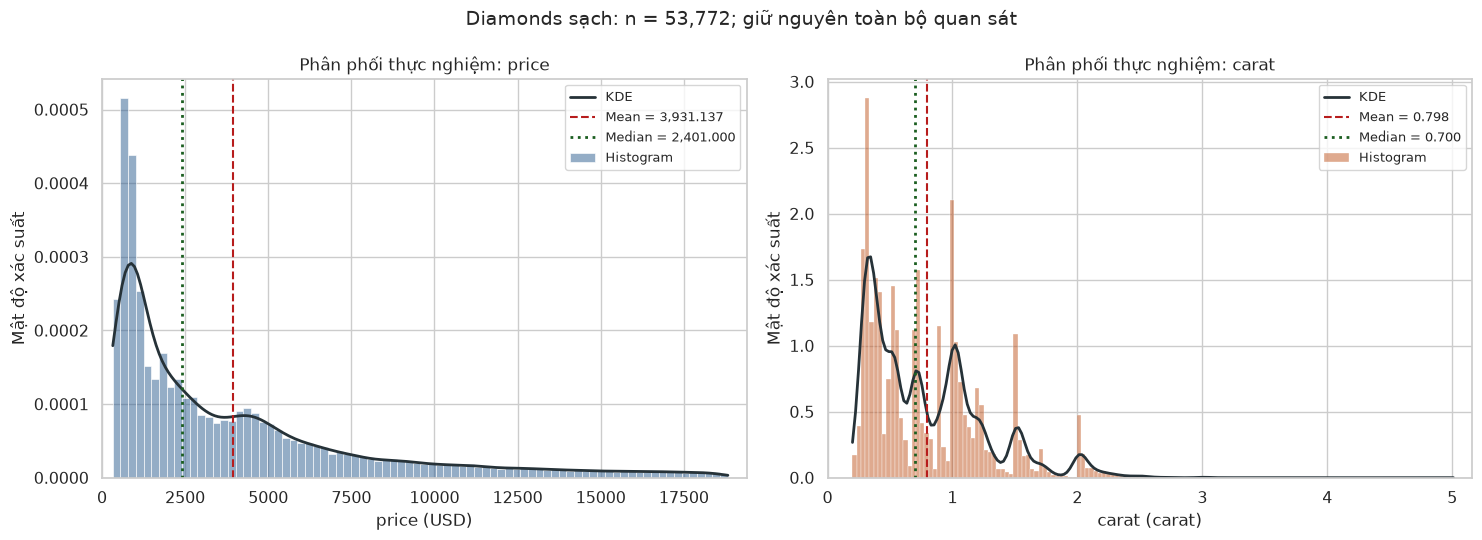

In [4]:
def save_figure(fig, filename):
    """Lưu PNG 300 dpi và hiển thị cùng một biểu đồ trong notebook."""
    target = FIGURES_DIR / filename
    fig.savefig(target, dpi=300, bbox_inches='tight', facecolor='white')
    saved_files.append(target)
    plt.show()
    plt.close(fig)

histogram_bins = {variable: np.histogram_bin_edges(df[variable], bins='fd') for variable in VARIABLES}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, variable, color in zip(axes, VARIABLES, ['#2b5c8f', '#c05621']):
    x = df[variable]
    sns.histplot(x=x, bins=histogram_bins[variable], stat='density', color=color,
                 alpha=0.5, edgecolor='white', ax=ax, label='Histogram')
    sns.kdeplot(x=x, cut=0, clip=(0, None), color='#263238', linewidth=2, ax=ax, label='KDE')
    ax.axvline(x.mean(), color='#b71c1c', linestyle='--', label=f'Mean = {x.mean():,.3f}')
    ax.axvline(x.median(), color='#1b5e20', linestyle=':', linewidth=2, label=f'Median = {x.median():,.3f}')
    ax.set(xlabel=f'{variable} ({UNITS[variable]})', ylabel='Mật độ xác suất',
           title=f'Phân phối thực nghiệm: {variable}', xlim=(0, x.max() * 1.03))
    ax.legend(fontsize=9)
fig.suptitle(f'Diamonds sạch: n = {len(df):,}; giữ nguyên toàn bộ quan sát', fontsize=14)
fig.tight_layout()
save_figure(fig, '01_histogram_kde_price_carat.png')

In [5]:
shape_notes = ['### Nhận xét định lượng về hình dạng']
for variable in VARIABLES:
    row = summary.loc[variable]
    direction = 'lệch phải' if row['Skewness'] > 0 else ('lệch trái' if row['Skewness'] < 0 else 'skewness bằng 0')
    shape_notes.append(
        f"- **{variable}:** mean = {row['Mean']:,.4f}, median = {row['Median']:,.4f} {UNITS[variable]}; "
        f"skewness = {row['Skewness']:.4f} ({direction}), excess kurtosis = {row['Excess kurtosis']:.4f}. "
        f"CV = {row['CV (%)']:.2f}%. Có {int(row['Số quan sát ngoài IQR']):,} quan sát ngoài ngưỡng IQR "
        f"({row['Tỷ lệ ngoài IQR (%)']:.2f}%), tất cả được giữ lại."
    )
shape_notes.append('Mean/median và độ lệch gợi ý ứng viên; chúng không thay thế kiểm định độ phù hợp.')
display(Markdown('\n\n'.join(shape_notes)))

### Nhận xét định lượng về hình dạng

- **price:** mean = 3,931.1373, median = 2,401.0000 USD; skewness = 1.6183 (lệch phải), excess kurtosis = 2.1797. CV = 101.39%. Có 3,519 quan sát ngoài ngưỡng IQR (6.54%), tất cả được giữ lại.

- **carat:** mean = 0.7975, median = 0.7000 carat; skewness = 1.1132 (lệch phải), excess kurtosis = 1.2460. CV = 59.33%. Có 1,867 quan sát ngoài ngưỡng IQR (3.47%), tất cả được giữ lại.

Mean/median và độ lệch gợi ý ứng viên; chúng không thay thế kiểm định độ phù hợp.

## 2.4. Mô hình, giả thuyết và phương pháp kiểm định

| Ứng viên | Mô hình | Tham số ước lượng | Miền |
| :--- | :--- | :--- | :--- |
| Normal | $X\sim N(\mu,\sigma^2)$ | $\mu=\bar{x}$; $\sigma=s$ với `ddof=1`, theo quy ước của `scipy.stats.goodness_of_fit` | Toàn bộ trục số |
| Lognormal | $\ln X\sim N(\mu_{\log},\sigma_{\log}^2)$ | `s` = SD của ln(X) với `ddof=0`; `scale` = exp(mean(ln(X))); cố định `loc=0` | $x>0$ |
| Exponential | $f(x)=\lambda e^{-\lambda x}$ | `scale` = mean(X); $\lambda=1/\text{scale}$; cố định `loc=0` | $x\geq0$ |

`loc=0` là lựa chọn mô hình cho giá/khối lượng dương, **không lấy min mẫu làm điểm gốc và không ước lượng thêm độ dịch chuyển**. Kết luận chỉ áp dụng cho lognormal hai tham số và exponential không dịch chuyển đã khai báo. Normal có thể gán xác suất cho giá/khối lượng âm; bảng sẽ báo phần xác suất này để nhận diện giới hạn về miền.

Với từng cặp biến–ứng viên:

- **$H_0$:** phân phối của biến thuộc họ ứng viên đã khai báo, với các tham số chưa biết được ước lượng từ mẫu.
- **$H_1$:** phân phối không thuộc họ đó.
- Dùng **Kolmogorov–Smirnov (KS)**: $D=\sup_x|F_n(x)-F_{\hat\theta}(x)|$. D càng lớn, sai khác giữa CDF thực nghiệm và CDF ứng viên càng lớn. D là độ chênh xác suất tích lũy tối đa, không phải tỷ lệ dòng dữ liệu sai.

**Vì sao bootstrap tham số?** P-value KS cổ điển giả định phân phối và tham số đã biết trước. Ở đây tham số được ước lượng từ chính mẫu, nên không lấy p-value của `kstest(x, fitted_cdf)` làm kết luận. Thay vào đó:

1. Fit ứng viên trên **toàn bộ n quan sát**, tính $D_{obs}$.
2. Mô phỏng **1.999 mẫu**, mỗi mẫu có đúng n quan sát từ ứng viên đã fit.
3. **Fit lại tham số chưa biết trên từng mẫu mô phỏng**, rồi tính D của mẫu đó.
4. Đếm $b$ mẫu có $D_{sim}\geq D_{obs}$; tính $\hat p=(b+1)/(B+1)$ với $B=1999$.

Code dùng `scipy.stats.goodness_of_fit(statistic='ks')`, chia lô 32 mẫu để giảm RAM và ghép các thống kê D mô phỏng. Seed cố định để tái lập. Không coi tham số đã fit là `known_params`; chỉ `loc=0` được cố định cho hai mô hình dương. Có sáu kiểm định, nên báo cả p thô và **p hiệu chỉnh Holm** để kiểm soát sai lầm loại I của cả nhóm kiểm định ở 5%.

**Quy tắc đọc:** p hiệu chỉnh < 0,05 ⇒ bác bỏ $H_0$; ngược lại ⇒ chưa đủ bằng chứng bác bỏ, không đồng nghĩa chứng minh $H_0$ đúng. P-value không phải xác suất mô hình đúng. Nếu $b=0$, $\hat p=0,0005$ là **sàn độ phân giải Monte Carlo**, không báo p bằng 0 hoặc khẳng định p thật đúng bằng 0,0005.

### Giới hạn của phương pháp

Các kiểm định này đánh giá **mô hình liên tục xấp xỉ dữ liệu ghi nhận**. Price được ghi theo USD và carat được làm tròn, tạo nhiều giá trị trùng; mô phỏng bootstrap chuẩn là liên tục và không mô phỏng cơ chế làm tròn. Vì vậy p-value là xấp xỉ dưới giả định liên tục, không phải kiểm định chính xác của một mô hình rời rạc đã làm tròn. Cần đọc thêm D, hình dạng đường CDF và Q–Q, thay vì chỉ dựa vào p rất nhỏ; không kết luận mọi sai khác đều do hình dạng hay đều do làm tròn.

Với cỡ mẫu lớn, sai khác nhỏ cũng có thể bị phát hiện. Giả định nền là các quan sát độc lập, cùng phân phối; notebook không thể xác nhận cách lấy mẫu từ một danh mục thương mại. Kết luận mô tả tập Diamonds nhóm đang dùng, không suy rộng thành quy luật cho mọi kim cương trên thị trường. Không dùng Shapiro–Wilk trên một mẫu con rồi thay kết quả đó cho toàn bộ dữ liệu.

In [6]:
# Khai báo ba họ ứng viên. known_params chỉ chứa tham số cố định theo mô hình.
MODEL_SPECS = {
    'normal': (stats.norm, None),
    'lognormal': (stats.lognorm, {'loc': 0}),
    'exponential': (stats.expon, {'loc': 0}),
}

def bootstrap_ks(dist, x, known_params, rng):
    """KS với fit lại tham số; ghép phân phối không từ các lô mô phỏng."""
    null_parts = []
    reference_statistic, reference_params = None, None
    completed = 0
    while completed < N_BOOTSTRAP:
        batch_size = min(BOOTSTRAP_BATCH, N_BOOTSTRAP - completed)
        result = stats.goodness_of_fit(
            dist, x, known_params=known_params, statistic='ks',
            n_mc_samples=batch_size, rng=rng,
        )
        if not result.fit_result.success:
            raise RuntimeError(f'Ước lượng không thành công: {result.fit_result.message}')
        if reference_statistic is None:
            reference_statistic = float(result.statistic)
            reference_params = tuple(float(value) for value in result.fit_result.params)
        elif not np.isclose(result.statistic, reference_statistic, rtol=1e-12, atol=1e-12):
            raise RuntimeError('Thống kê quan sát không nhất quán giữa các lô bootstrap.')
        null_parts.append(np.asarray(result.null_distribution))
        completed += batch_size

    null_distribution = np.concatenate(null_parts)
    if len(null_distribution) != N_BOOTSTRAP or not np.isfinite(null_distribution).all():
        raise RuntimeError('Phân phối D mô phỏng không hợp lệ.')
    exceedances = int(np.count_nonzero(null_distribution >= reference_statistic))
    p_bootstrap = (exceedances + 1) / (N_BOOTSTRAP + 1)
    return reference_statistic, p_bootstrap, exceedances, reference_params

result_rows = []
fitted_models = {}
test_start = perf_counter()
for variable_index, variable in enumerate(VARIABLES):
    x = df[variable].to_numpy(dtype=float)
    for model_index, model_name in enumerate(MODEL_ORDER):
        distribution, known = MODEL_SPECS[model_name]
        # Mỗi cặp dùng luồng ngẫu nhiên riêng, không phụ thuộc trạng thái kernel trước đó.
        rng = np.random.default_rng(np.random.SeedSequence([SEED, variable_index, model_index]))
        d_stat, p_raw, exceedances, params = bootstrap_ks(distribution, x, known, rng)
        fitted = distribution(*params)
        fitted_models[(variable, model_name)] = fitted

        if model_name == 'normal':
            loc, scale = params
            parameter_text = f'mu={loc:.6g}; sigma={scale:.6g}'
            shape, log_mu, rate = np.nan, np.nan, np.nan
        elif model_name == 'lognormal':
            shape, loc, scale = params
            log_mu, rate = np.log(scale), np.nan
            parameter_text = f'mu_log={log_mu:.6g}; sigma_log={shape:.6g}; loc=0'
        else:
            loc, scale = params
            shape, log_mu, rate = np.nan, np.nan, 1 / scale
            parameter_text = f'lambda={rate:.6g}; scale={scale:.6g}; loc=0'

        # Kiểm tra D độc lập; chỉ dùng statistic, không dùng p-value KS cổ điển.
        d_crosscheck = stats.kstest(x, fitted.cdf).statistic
        if not np.isclose(d_stat, d_crosscheck, rtol=1e-10, atol=1e-12):
            raise RuntimeError('D bootstrap không khớp D của CDF đã ước lượng.')

        result_rows.append({
            'variable': variable, 'model': model_name, 'n': len(x),
            'parameters': parameter_text, 'loc': loc, 'scale': scale,
            'shape_s': shape, 'mu_log': log_mu, 'lambda': rate,
            'D_KS': d_stat, 'p_bootstrap': p_raw, 'bootstrap_exceedances': exceedances,
            'B': N_BOOTSTRAP, 'p_MC_floor': 1 / (N_BOOTSTRAP + 1),
            'model_probability_below_zero': float(fitted.cdf(0)),
        })
        print(f'{variable:5s} | {model_name:11s} | D={d_stat:.6f} | '
              f'p_MC={p_raw:.6f} | vượt ngưỡng={exceedances}/{N_BOOTSTRAP}', flush=True)

results = pd.DataFrame(result_rows)
reject, p_holm, _, _ = multipletests(results['p_bootstrap'], alpha=ALPHA, method='holm')
results['p_holm'] = p_holm
results['reject_H0_5pct_Holm'] = reject
results['decision'] = np.where(reject, 'Bác bỏ H0 ở mức 5% (Holm)', 'Chưa đủ bằng chứng bác bỏ H0 (Holm)')
test_seconds = perf_counter() - test_start
export_csv(results, 'distribution_test_results.csv')
print(f'Tổng thời gian kiểm định: {test_seconds:.1f} giây.')

price | normal      | D=0.184567 | p_MC=0.000500 | vượt ngưỡng=0/1999


price | lognormal   | D=0.084169 | p_MC=0.000500 | vượt ngưỡng=0/1999


price | exponential | D=0.093867 | p_MC=0.000500 | vượt ngưỡng=0/1999


carat | normal      | D=0.122582 | p_MC=0.000500 | vượt ngưỡng=0/1999


carat | lognormal   | D=0.103606 | p_MC=0.000500 | vượt ngưỡng=0/1999


carat | exponential | D=0.283774 | p_MC=0.000500 | vượt ngưỡng=0/1999


Tổng thời gian kiểm định: 45.5 giây.


In [7]:
print('BẢNG KIỂM ĐỊNH: đọc p_holm cùng D_KS, không dùng p-value KS chưa hiệu chỉnh tham số.')
display(results[['variable', 'model', 'n', 'D_KS', 'p_bootstrap', 'p_holm',
                 'bootstrap_exceedances', 'B', 'decision']])
print('THAM SỐ ƯỚC LƯỢNG VÀ GIỚI HẠN MIỀN CỦA MÔ HÌNH:')
display(results[['variable', 'model', 'parameters', 'model_probability_below_zero']])

floor_rows = results[results['bootstrap_exceedances'] == 0]
if not floor_rows.empty:
    print(f'{len(floor_rows)} kiểm định không có mẫu mô phỏng nào vượt D quan sát. '
          f'p_MC = {1 / (N_BOOTSTRAP + 1):.6f} là sàn Monte Carlo; p thật chưa biết chính xác.')

BẢNG KIỂM ĐỊNH: đọc p_holm cùng D_KS, không dùng p-value KS chưa hiệu chỉnh tham số.


,variable,model,n,D_KS,p_bootstrap,p_holm,bootstrap_exceedances,B,decision
0,price,normal,53772,0.184567,0.000500,0.003000,0,1999,Bác bỏ H0 ở mức 5% (Holm)
1,price,lognormal,53772,0.084169,0.000500,0.003000,0,1999,Bác bỏ H0 ở mức 5% (Holm)
2,price,exponential,53772,0.093867,0.000500,0.003000,0,1999,Bác bỏ H0 ở mức 5% (Holm)
3,carat,normal,53772,0.122582,0.000500,0.003000,0,1999,Bác bỏ H0 ở mức 5% (Holm)
4,carat,lognormal,53772,0.103606,0.000500,0.003000,0,1999,Bác bỏ H0 ở mức 5% (Holm)
5,carat,exponential,53772,0.283774,0.000500,0.003000,0,1999,Bác bỏ H0 ở mức 5% (Holm)


THAM SỐ ƯỚC LƯỢNG VÀ GIỚI HẠN MIỀN CỦA MÔ HÌNH:


,variable,model,parameters,model_probability_below_zero
0,price,normal,mu=3931.14; sigma=3985.85,0.162000
1,price,lognormal,mu_log=7.78674; sigma_log=1.01431; loc=0,0.000000
2,price,exponential,lambda=0.000254379; scale=3931.14; loc=0,0.000000
3,carat,normal,mu=0.797525; sigma=0.47315,0.045940
4,carat,lognormal,mu_log=-0.395169; sigma_log=0.584353; loc=0,0.000000
5,carat,exponential,lambda=1.25388; scale=0.797525; loc=0,0.000000


6 kiểm định không có mẫu mô phỏng nào vượt D quan sát. p_MC = 0.000500 là sàn Monte Carlo; p thật chưa biết chính xác.


## 2.5. Đối chiếu với đường phân phối lý thuyết

Mỗi đường PDF dùng **chính tham số của kiểm định ở trên**, không fit riêng để làm đồ thị đẹp hơn. Histogram và KDE cho dữ liệu thực nghiệm, PDF biểu diễn ứng viên đã fit. Đường gần histogram hơn chỉ gợi ý độ phù hợp tương đối; không đủ để khẳng định cả phân phối đúng, nhất là ở đuôi.

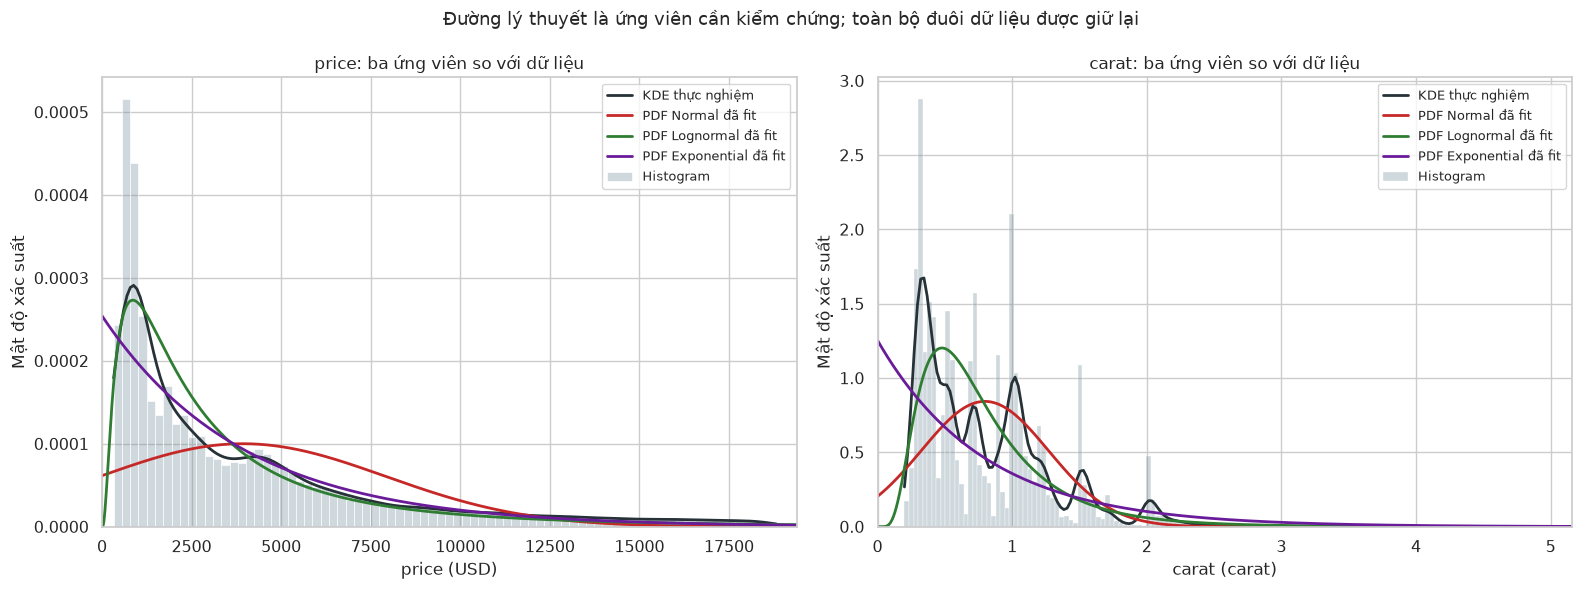

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, variable in zip(axes, VARIABLES):
    x = df[variable].to_numpy(dtype=float)
    grid = np.linspace(0, x.max() * 1.03, 1600)
    sns.histplot(x=x, bins=histogram_bins[variable], stat='density',
                 color='#78909c', alpha=0.35, edgecolor='white', ax=ax, label='Histogram')
    sns.kdeplot(x=x, cut=0, clip=(0, None), color='#263238', linewidth=2,
                ax=ax, label='KDE thực nghiệm')
    for model_name in MODEL_ORDER:
        fitted = fitted_models[(variable, model_name)]
        ax.plot(grid, fitted.pdf(grid), color=MODEL_COLORS[model_name],
                linewidth=2, label=f'PDF {MODEL_LABELS[model_name]} đã fit')
    ax.set(title=f'{variable}: ba ứng viên so với dữ liệu', xlabel=f'{variable} ({UNITS[variable]})',
           ylabel='Mật độ xác suất', xlim=(0, grid[-1]), ylim=(0, None))
    ax.legend(fontsize=9)
fig.suptitle('Đường lý thuyết là ứng viên cần kiểm chứng; toàn bộ đuôi dữ liệu được giữ lại', fontsize=13)
fig.tight_layout()
save_figure(fig, '02_theoretical_pdf_price_carat.png')

### Q–Q plot cho cả ba ứng viên

Trục ngang là phân vị lý thuyết của mô hình đã fit; trục dọc là giá trị quan sát đã sắp xếp. Dùng xác suất $(i-0.5)/n$ để tránh phân vị tại 0 và 1. Vẽ **đủ n điểm**, không lấy mẫu con và không bỏ giá trị cực đại.

Nếu ứng viên mô tả tốt, các điểm nằm gần đường **y = x** trên cả miền. Độ cong, đoạn bậc thang hoặc lệch rõ ở hai đầu cho thấy sai khác ở thân/đuôi. Điểm ở dưới đường tại phía phải nghĩa là phân vị lý thuyết lớn hơn dữ liệu tại vùng đó. Không thay đường y=x bằng một đường hồi quy tự fit, vì việc đó có thể che sai khác của mô hình đang kiểm định.

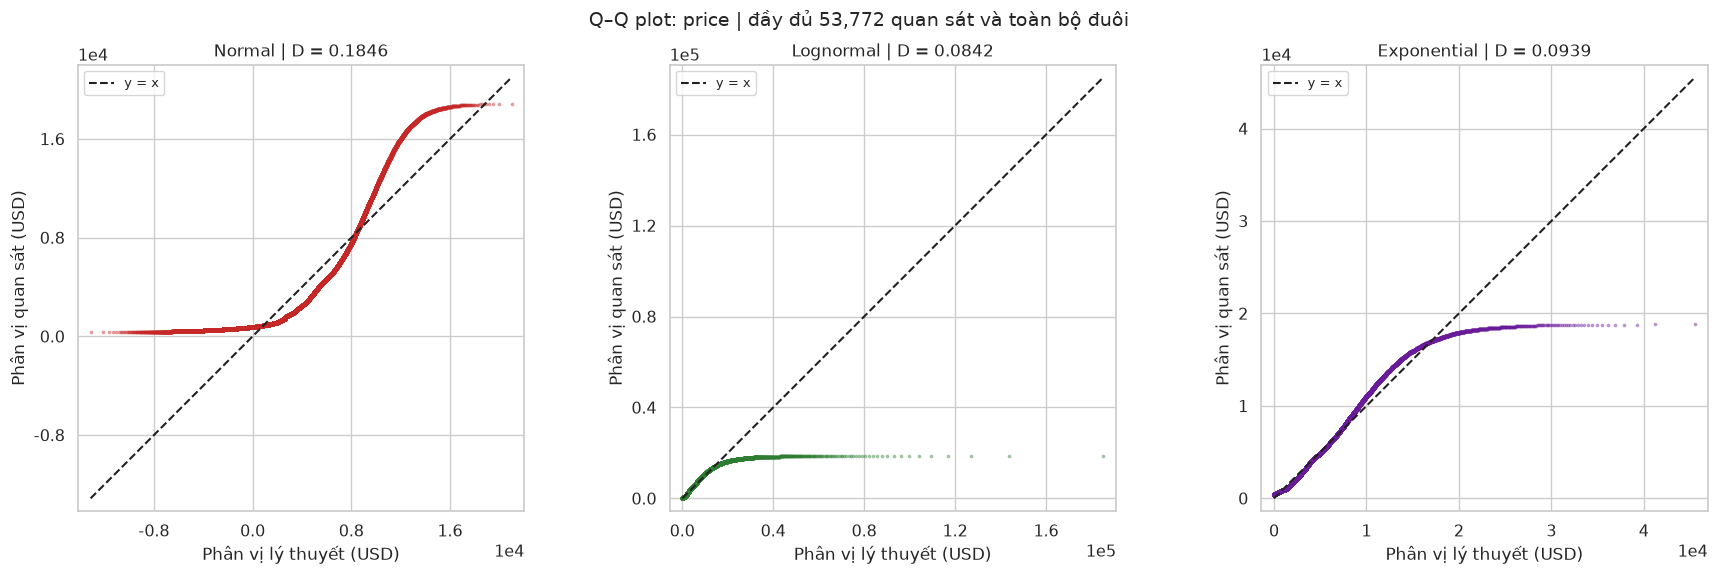

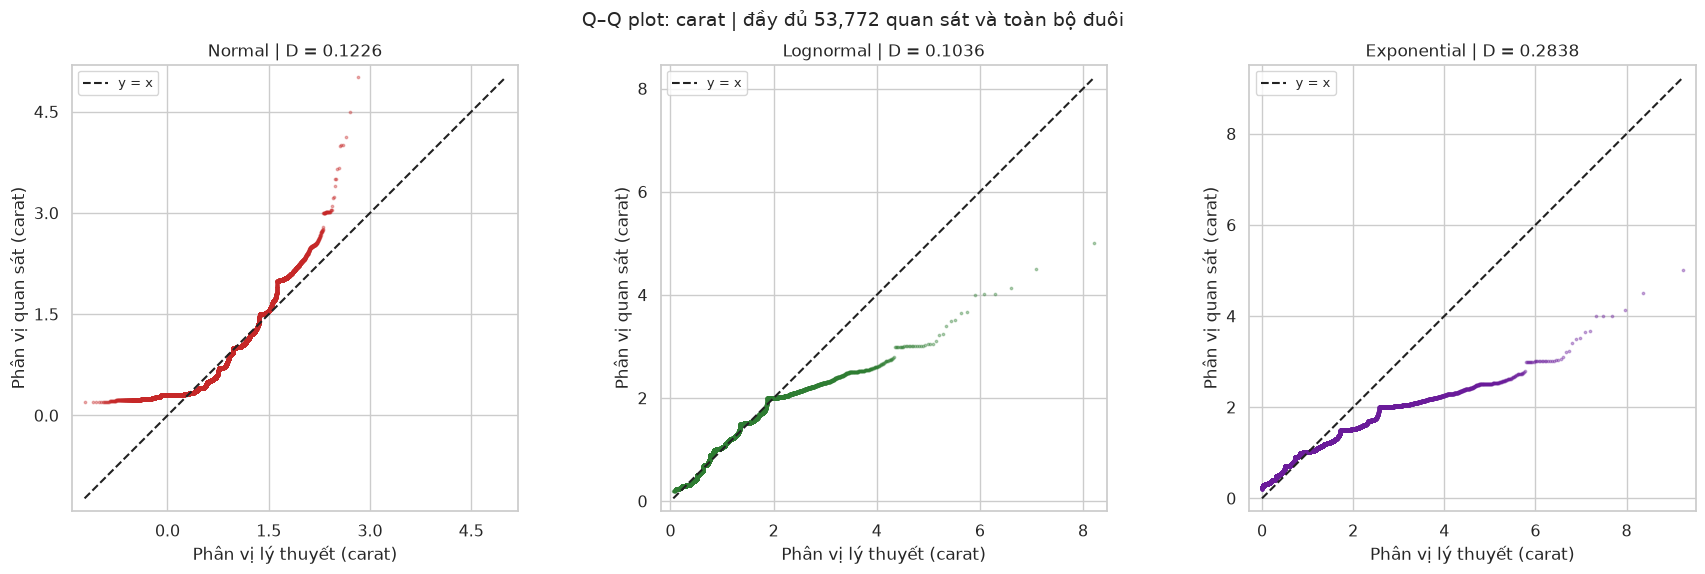

In [9]:
for variable in VARIABLES:
    observed = np.sort(df[variable].to_numpy(dtype=float))
    probabilities = (np.arange(1, len(observed) + 1) - 0.5) / len(observed)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.7))
    for ax, model_name in zip(axes, MODEL_ORDER):
        theoretical = fitted_models[(variable, model_name)].ppf(probabilities)
        ax.scatter(theoretical, observed, s=3, alpha=0.35,
                   color=MODEL_COLORS[model_name], rasterized=True)
        low = min(theoretical.min(), observed.min())
        high = max(theoretical.max(), observed.max())
        ax.plot([low, high], [low, high], '--', color='#212121', linewidth=1.5, label='y = x')
        margin = (high - low) * 0.03
        ax.set_xlim(low - margin, high + margin)
        ax.set_ylim(low - margin, high + margin)
        ax.set_aspect('equal', adjustable='box')
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        if variable == 'price':
            ax.ticklabel_format(axis='both', style='sci', scilimits=(0, 0))
        test_row = results[(results['variable'] == variable) & (results['model'] == model_name)].iloc[0]
        ax.set(title=f"{MODEL_LABELS[model_name]} | D = {test_row['D_KS']:.4f}",
               xlabel=f'Phân vị lý thuyết ({UNITS[variable]})', ylabel=f'Phân vị quan sát ({UNITS[variable]})')
        ax.legend(fontsize=9)
    fig.suptitle(f'Q–Q plot: {variable} | đầy đủ {len(observed):,} quan sát và toàn bộ đuôi', fontsize=14)
    fig.tight_layout()
    number = '03' if variable == 'price' else '04'
    save_figure(fig, f'{number}_qq_{variable}_all_candidates.png')

### CDF thực nghiệm và độ chênh xác suất tích lũy

Biểu đồ phía trên so sánh $F_n(x)=\#\{X_i\leq x\}/n$ với CDF ứng viên. Phía dưới thể hiện cả $F_n(x)-F_{\hat\theta}(x)$ (chấm đặc, sau bước nhảy) và $F_n(x^-)-F_{\hat\theta}(x)$ (chấm rỗng, trước bước nhảy), trong đó $F_n(x^-)=\#\{X_i<x\}/n$. Các đoạn thẳng đứng nối hai phía tại cùng x biểu diễn bước nhảy do giá trị lặp; màu vẫn tương ứng với từng ứng viên.

Giá trị dương nghĩa là tỷ lệ tích lũy thực nghiệm cao hơn CDF mô hình tại phía đang xét. KS lấy độ lệch tuyệt đối lớn nhất trên **cả hai phía**; code đối chiếu giá trị này với `D_KS` đã tính ở mục 2.4. Đồ thị giúp thấy sai khác ở đâu và lớn bao nhiêu, bổ sung cho p-value vốn rất nhạy khi n lớn.


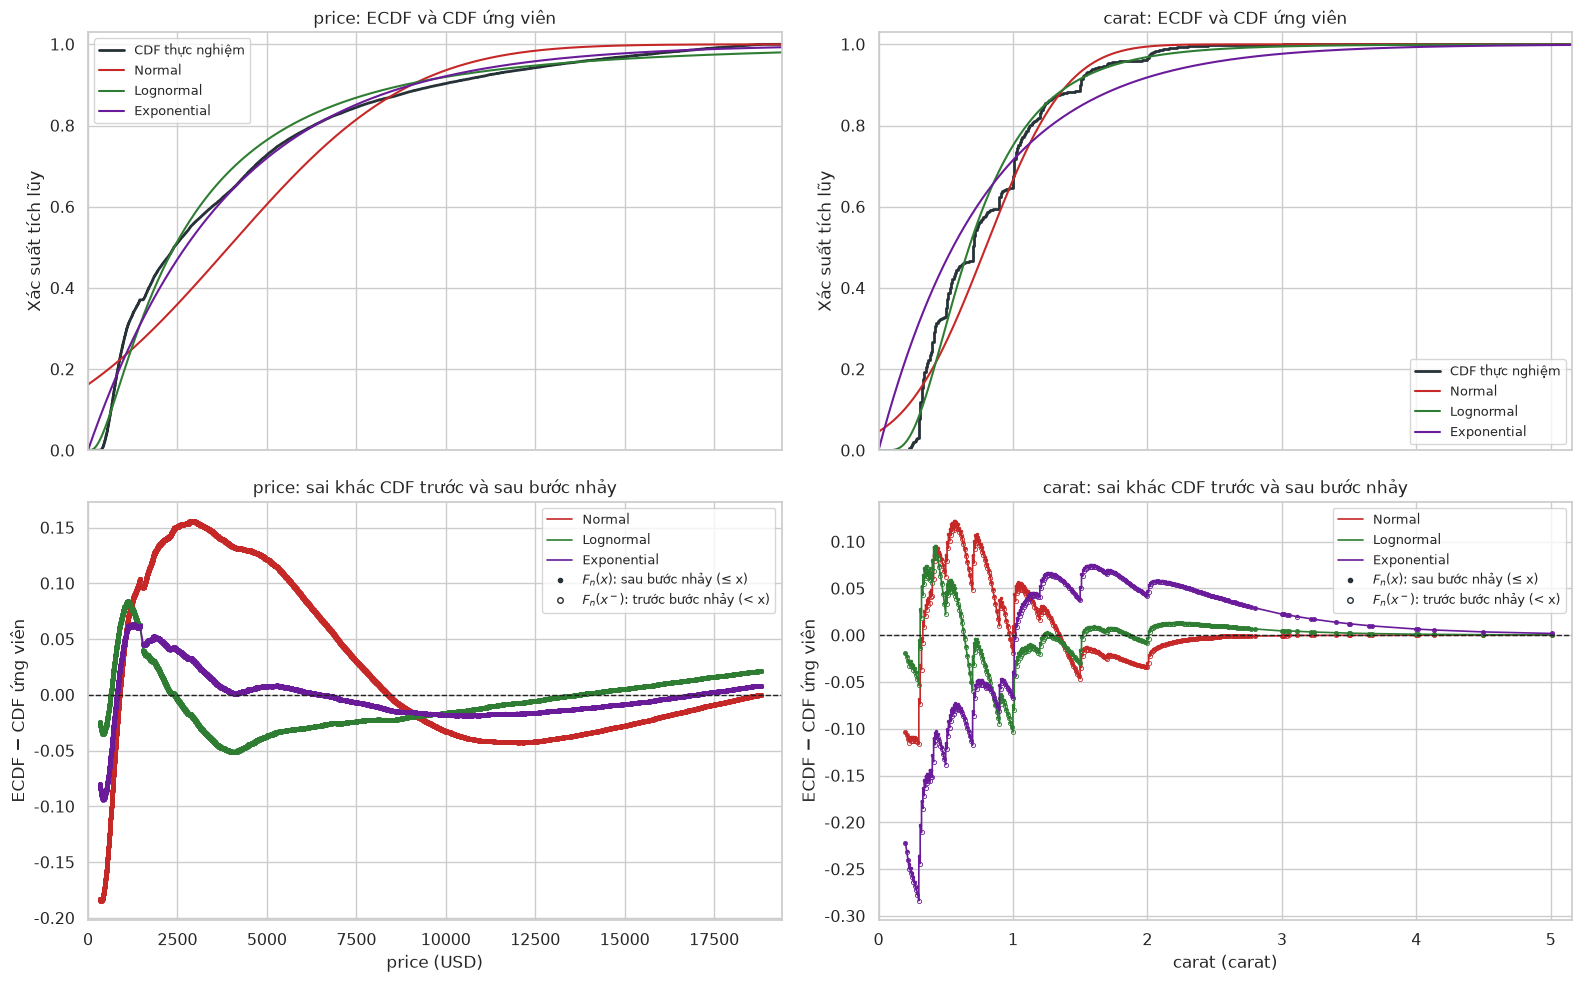

Đối chiếu độ lệch lớn nhất của cả hai phía ECDF với D_KS:


,variable,model,D_CDF_both_sides,D_KS,absolute_error
0,price,normal,0.184567,0.184567,0.000000
1,price,lognormal,0.084169,0.084169,0.000000
2,price,exponential,0.093867,0.093867,0.000000
3,carat,normal,0.122582,0.122582,0.000000
4,carat,lognormal,0.103606,0.103606,0.000000
5,carat,exponential,0.283774,0.283774,0.000000


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex='col')
cdf_checks = []
for column, variable in enumerate(VARIABLES):
    values, counts = np.unique(df[variable].to_numpy(dtype=float), return_counts=True)
    n = counts.sum()
    cumulative_counts = counts.cumsum()
    ecdf = cumulative_counts / n  # F_n(x): tỷ lệ quan sát <= x.
    ecdf_before = (cumulative_counts - counts) / n  # F_n(x^-): tỷ lệ quan sát < x.
    jump_values = np.repeat(values, 2)
    grid = np.linspace(0, values.max() * 1.03, 1800)
    axes[0, column].step(np.r_[0, values, grid[-1]], np.r_[0, ecdf, 1], where='post',
                          color='#263238', linewidth=2, label='CDF thực nghiệm')
    for model_name in MODEL_ORDER:
        fitted = fitted_models[(variable, model_name)]
        color = MODEL_COLORS[model_name]
        theoretical_cdf = fitted.cdf(values)
        difference_after = ecdf - theoretical_cdf
        difference_before = ecdf_before - theoretical_cdf
        # Lặp x và xen kẽ trước/sau để vẽ đủ các bước nhảy, kể cả khi có ties.
        jump_differences = np.column_stack((difference_before, difference_after)).ravel()
        axes[0, column].plot(grid, fitted.cdf(grid), color=color, label=MODEL_LABELS[model_name])
        axes[1, column].plot(jump_values, jump_differences, color=color,
                             label=MODEL_LABELS[model_name], linewidth=1.2)
        axes[1, column].plot(values, difference_after, linestyle='none', marker='.',
                             markersize=3, color=color)
        axes[1, column].plot(values, difference_before, linestyle='none', marker='o',
                             markersize=3, markerfacecolor='none', markeredgewidth=0.6, color=color)

        d_from_cdf = max(np.abs(difference_before).max(), np.abs(difference_after).max())
        test_row = results[(results['variable'] == variable) & (results['model'] == model_name)].iloc[0]
        if not np.isclose(d_from_cdf, test_row['D_KS'], rtol=1e-10, atol=1e-12):
            raise RuntimeError(f'{variable}–{model_name}: sai khác CDF hai phía không khớp D_KS.')
        cdf_checks.append({'variable': variable, 'model': model_name,
                           'D_CDF_both_sides': d_from_cdf, 'D_KS': test_row['D_KS'],
                           'absolute_error': abs(d_from_cdf - test_row['D_KS'])})
    axes[0, column].set(title=f'{variable}: ECDF và CDF ứng viên', ylabel='Xác suất tích lũy',
                        ylim=(0, 1.03), xlim=(0, grid[-1]))
    axes[1, column].axhline(0, color='#212121', linestyle='--', linewidth=1)
    axes[1, column].set(title=f'{variable}: sai khác CDF trước và sau bước nhảy',
                        xlabel=f'{variable} ({UNITS[variable]})', ylabel='ECDF − CDF ứng viên')
    # Chú giải ký hiệu dùng chung; màu của các điểm vẫn theo từng phân phối.
    axes[1, column].plot([], [], linestyle='none', marker='.', markersize=6, color='#263238',
                         label=r'$F_n(x)$: sau bước nhảy (≤ x)')
    axes[1, column].plot([], [], linestyle='none', marker='o', markersize=4, color='#263238',
                         markerfacecolor='none', label=r'$F_n(x^-)$: trước bước nhảy (< x)')
    axes[0, column].legend(fontsize=9)
    axes[1, column].legend(fontsize=9)
fig.tight_layout()
save_figure(fig, '05_ecdf_theoretical_cdf_comparison.png')
print('Đối chiếu độ lệch lớn nhất của cả hai phía ECDF với D_KS:')
display(pd.DataFrame(cdf_checks))


## 2.6. Xác suất thực nghiệm: diễn giải không cần ép một mô hình

Khi ứng viên chưa mô tả tốt toàn bộ dữ liệu, vẫn có thể trả lời câu hỏi xác suất bằng **tỷ lệ thực tế trong mẫu**. Các mốc dưới đây được chọn để mô tả tỷ lệ quan sát theo các ngưỡng giá và khối lượng. Đây là xác suất thực nghiệm của tập sạch, không phải xác suất suy rộng cho thị trường và không phải dự đoán từ một ứng viên bị bác bỏ.

In [11]:
events = [
    ('price <= 1.000 USD', df['price'] <= 1000),
    ('price > 5.000 USD', df['price'] > 5000),
    ('price > 10.000 USD', df['price'] > 10000),
    ('carat <= 0,5 carat', df['carat'] <= 0.5),
    ('carat >= 1 carat', df['carat'] >= 1),
    ('carat >= 2 carat', df['carat'] >= 2),
]
empirical_probabilities = pd.DataFrame([
    {'Sự kiện': name, 'Số quan sát': int(mask.sum()), 'n': len(df),
     'Xác suất thực nghiệm': mask.mean(), 'Tỷ lệ (%)': 100 * mask.mean()}
    for name, mask in events
])
display(empirical_probabilities)
export_csv(empirical_probabilities, 'empirical_probabilities.csv')

,Sự kiện,Số quan sát,n,Xác suất thực nghiệm,Tỷ lệ (%)
0,price <= 1.000 USD,14470,53772,0.269099,26.909916
1,price > 5.000 USD,14666,53772,0.272744,27.274418
2,price > 10.000 USD,5194,53772,0.096593,9.659302
3,"carat <= 0,5 carat",18863,53772,0.350796,35.079595
4,carat >= 1 carat,18984,53772,0.353046,35.304620
5,carat >= 2 carat,2129,53772,0.039593,3.959310


## 2.7. Kết luận

Ô sau tự tạo nhận xét từ các bảng đã tính. Phân biệt rõ:

1. **Đặc điểm thực nghiệm:** lệch, phân tán, ngoại lai hợp lệ và xác suất theo mẫu.
2. **Kết quả kiểm định:** bác bỏ hay chưa đủ bằng chứng bác bỏ mô hình ở mức 5% sau Holm.
3. **So sánh tương đối:** D nhỏ nhất chỉ nói ứng viên nào ít sai khác CDF nhất trong ba mô hình, không chứng minh nó phù hợp tuyệt đối.

Nếu cả ba ứng viên đều bị bác bỏ, kết luận đúng là **ba mô hình đã thử chưa mô tả tốt toàn bộ dữ liệu** dưới các giả định đã nêu. Không đổi kết luận thành “lognormal” chỉ vì histogram lệch phải hoặc logarithm trông bớt lệch. Việc tìm mô hình khác, mô hình hỗn hợp hay phân tầng theo thuộc tính cần phân tích riêng và kiểm chứng tiếp.

In [12]:
conclusion_parts = [
    '# Nhận xét phần 2 — Diamonds',
    f'Dữ liệu sạch thực tế: **{len(df):,} dòng × {df.shape[1]} cột**. '
    f'Kiểm định KS bootstrap tham số: B={N_BOOTSTRAP}, seed={SEED}, mức ý nghĩa {ALPHA:.0%}; '
    'đánh giá sáu giả thuyết bằng hiệu chỉnh Holm.',
]
for variable in VARIABLES:
    row = summary.loc[variable]
    subset = results[results['variable'] == variable]
    best = subset.loc[subset['D_KS'].idxmin()]
    decisions = []
    for test_row in subset.itertuples(index=False):
        word = 'bác bỏ H0' if test_row.reject_H0_5pct_Holm else 'chưa đủ bằng chứng bác bỏ H0'
        mc_note = ' (sàn Monte Carlo, không phải p thật đã biết)' if test_row.bootstrap_exceedances == 0 else ''
        decisions.append(
            f"{MODEL_LABELS[test_row.model]}: D={test_row.D_KS:.6f}; "
            f"p_MC={test_row.p_bootstrap:.6f}{mc_note}; p_Holm={test_row.p_holm:.6f} ⇒ {word}"
        )
    all_rejected = bool(subset['reject_H0_5pct_Holm'].all())
    normal_negative_pct = 100 * fitted_models[(variable, 'normal')].cdf(0)
    theoretical_p99_text = '; '.join(
        f"{MODEL_LABELS[name]} = {fitted_models[(variable, name)].ppf(0.99):,.4f}"
        for name in MODEL_ORDER
    )
    model_statement = (
        'Cả ba ứng viên đều bị bác bỏ ở mức 5% sau Holm; không gán biến cho một phân phối đã thử.'
        if all_rejected else
        'Có ứng viên chưa bị bác bỏ; điều này chỉ cho thấy chưa đủ bằng chứng chống lại mô hình, không chứng minh mô hình đúng.'
    )
    direction = 'lệch phải' if row['Skewness'] > 0 else ('lệch trái' if row['Skewness'] < 0 else 'skewness bằng 0')
    conclusion_parts.append(
        f"## {variable} ({UNITS[variable]})\n\n"
        f"Mean = **{row['Mean']:,.4f}**, median = **{row['Median']:,.4f}**, "
        f"SD = {row['SD (ddof=1)']:,.4f}, CV = {row['CV (%)']:.2f}%. "
        f"Skewness = **{row['Skewness']:.4f}** ({direction}); excess kurtosis = {row['Excess kurtosis']:.4f}. "
        f"Khoảng ghi nhận từ {row['Min']:,.4f} đến {row['Max']:,.4f}; "
        f"Q1 = {row['Q1']:,.4f}, Q3 = {row['Q3']:,.4f}. "
        f"Giữ lại {int(row['Số quan sát ngoài IQR']):,} quan sát vượt ngưỡng IQR "
        f"({row['Tỷ lệ ngoài IQR (%)']:.2f}%).\n\n"
        + '\n\n'.join(f'- {decision}' for decision in decisions)
        + f"\n\n{model_statement} {MODEL_LABELS[best['model']]} có D nhỏ nhất trong ba ứng viên "
        f"(D={best['D_KS']:.6f}, tương ứng độ chênh CDF tối đa khoảng {100 * best['D_KS']:.2f} điểm phần trăm); "
        'đây là so sánh tương đối, không thay thế kết luận kiểm định.'
        f"\n\n**Đọc đuôi trên cùng Q–Q plot:** P99 thực nghiệm = {row['P99']:,.4f} {UNITS[variable]}; "
        f"P99 dự đoán bởi các mô hình đã fit: {theoretical_p99_text} {UNITS[variable]}. "
        'Mô hình có P99 lớn hơn thực nghiệm dự đoán phân vị này cao hơn dữ liệu; '
        'mô hình có P99 nhỏ hơn dự đoán thấp hơn dữ liệu. Sai khác có thể quan sát trên Q–Q, '
        'và việc một phân vị gần nhau chưa bảo đảm cả phân phối phù hợp. '
        f"Normal còn gán **{normal_negative_pct:.2f}%** xác suất cho {variable} âm, "
        'không phù hợp miền vật lý/kinh tế của biến.'
    )

carat_modes = df['carat'].value_counts().head(3)
conclusion_parts.append(
    '## Các mốc tập trung của carat\n\n'
    + '; '.join(f'{value:.2f} carat: {int(count):,} quan sát ({100 * count / len(df):.2f}%)'
                for value, count in carat_modes.items())
    + '. Histogram/KDE và ECDF thể hiện các vùng tập trung, Q–Q có các đoạn bậc thang '
    'do giá trị lặp. Ba mô hình mật độ trơn đã thử không tái hiện đầy đủ cấu trúc này. '
    'Chưa đủ căn cứ quy các đỉnh cho một nguyên nhân thị trường cụ thể.'
)

conclusion_parts.append('## Xác suất thực nghiệm đáng chú ý\n\n' + '\n'.join(
    f"- **{row['Sự kiện']}**: {int(row['Số quan sát']):,}/{int(row['n']):,} quan sát = **{row['Tỷ lệ (%)']:.2f}%**."
    for _, row in empirical_probabilities.iterrows()
))
conclusion_parts.append(
    '## Giới hạn phương pháp\n\n'
    'Price được ghi theo USD nguyên; carat nằm trên lưới 0,01 carat, nên có nhiều giá trị trùng. '
    'Bootstrap hiện mô phỏng phân phối liên tục và fit lại tham số, chưa mô phỏng cơ chế làm tròn. '
    'P-value được diễn giải dưới các giả định đã nêu, bao gồm các quan sát độc lập, cùng phân phối '
    'và mô hình liên tục; cần đọc cùng D, histogram/KDE, Q–Q và ECDF.\n\n'
    'Lognormal có D nhỏ nhất trong ba ứng viên không đồng nghĩa dữ liệu tuân theo lognormal. '
    f'Khi không có mẫu mô phỏng vượt D quan sát, p_MC = 1/(B+1) = {1 / (N_BOOTSTRAP + 1):.4f} '
    'là sàn Monte Carlo, không phải p-value thật đã biết chính xác.\n\n'
    'Kết luận áp dụng cho tập Diamonds đang phân tích; chưa đủ cơ sở suy rộng '
    'cho toàn bộ thị trường kim cương.'
)
conclusion_markdown = '\n\n'.join(conclusion_parts)
display(Markdown(conclusion_markdown))
conclusion_path = FIGURES_DIR / 'nhan_xet_phan2.md'
conclusion_path.write_text(conclusion_markdown + '\n', encoding='utf-8')
saved_files.append(conclusion_path)

# Nhận xét phần 2 — Diamonds

Dữ liệu sạch thực tế: **53,772 dòng × 10 cột**. Kiểm định KS bootstrap tham số: B=1999, seed=42, mức ý nghĩa 5%; đánh giá sáu giả thuyết bằng hiệu chỉnh Holm.

## price (USD)

Mean = **3,931.1373**, median = **2,401.0000**, SD = 3,985.8530, CV = 101.39%. Skewness = **1.6183** (lệch phải); excess kurtosis = 2.1797. Khoảng ghi nhận từ 326.0000 đến 18,823.0000; Q1 = 951.0000, Q3 = 5,324.0000. Giữ lại 3,519 quan sát vượt ngưỡng IQR (6.54%).

- Normal: D=0.184567; p_MC=0.000500 (sàn Monte Carlo, không phải p thật đã biết); p_Holm=0.003000 ⇒ bác bỏ H0

- Lognormal: D=0.084169; p_MC=0.000500 (sàn Monte Carlo, không phải p thật đã biết); p_Holm=0.003000 ⇒ bác bỏ H0

- Exponential: D=0.093867; p_MC=0.000500 (sàn Monte Carlo, không phải p thật đã biết); p_Holm=0.003000 ⇒ bác bỏ H0

Cả ba ứng viên đều bị bác bỏ ở mức 5% sau Holm; không gán biến cho một phân phối đã thử. Lognormal có D nhỏ nhất trong ba ứng viên (D=0.084169, tương ứng độ chênh CDF tối đa khoảng 8.42 điểm phần trăm); đây là so sánh tương đối, không thay thế kết luận kiểm định.

**Đọc đuôi trên cùng Q–Q plot:** P99 thực nghiệm = 17,365.2900 USD; P99 dự đoán bởi các mô hình đã fit: Normal = 13,203.6180; Lognormal = 25,498.7181; Exponential = 18,103.5564 USD. Mô hình có P99 lớn hơn thực nghiệm dự đoán phân vị này cao hơn dữ liệu; mô hình có P99 nhỏ hơn dự đoán thấp hơn dữ liệu. Sai khác có thể quan sát trên Q–Q, và việc một phân vị gần nhau chưa bảo đảm cả phân phối phù hợp. Normal còn gán **16.20%** xác suất cho price âm, không phù hợp miền vật lý/kinh tế của biến.

## carat (carat)

Mean = **0.7975**, median = **0.7000**, SD = 0.4732, CV = 59.33%. Skewness = **1.1132** (lệch phải); excess kurtosis = 1.2460. Khoảng ghi nhận từ 0.2000 đến 5.0100; Q1 = 0.4000, Q3 = 1.0400. Giữ lại 1,867 quan sát vượt ngưỡng IQR (3.47%).

- Normal: D=0.122582; p_MC=0.000500 (sàn Monte Carlo, không phải p thật đã biết); p_Holm=0.003000 ⇒ bác bỏ H0

- Lognormal: D=0.103606; p_MC=0.000500 (sàn Monte Carlo, không phải p thật đã biết); p_Holm=0.003000 ⇒ bác bỏ H0

- Exponential: D=0.283774; p_MC=0.000500 (sàn Monte Carlo, không phải p thật đã biết); p_Holm=0.003000 ⇒ bác bỏ H0

Cả ba ứng viên đều bị bác bỏ ở mức 5% sau Holm; không gán biến cho một phân phối đã thử. Lognormal có D nhỏ nhất trong ba ứng viên (D=0.103606, tương ứng độ chênh CDF tối đa khoảng 10.36 điểm phần trăm); đây là so sánh tương đối, không thay thế kết luận kiểm định.

**Đọc đuôi trên cùng Q–Q plot:** P99 thực nghiệm = 2.1700 carat; P99 dự đoán bởi các mô hình đã fit: Normal = 1.8982; Lognormal = 2.6228; Exponential = 3.6727 carat. Mô hình có P99 lớn hơn thực nghiệm dự đoán phân vị này cao hơn dữ liệu; mô hình có P99 nhỏ hơn dự đoán thấp hơn dữ liệu. Sai khác có thể quan sát trên Q–Q, và việc một phân vị gần nhau chưa bảo đảm cả phân phối phù hợp. Normal còn gán **4.59%** xác suất cho carat âm, không phù hợp miền vật lý/kinh tế của biến.

## Các mốc tập trung của carat

0.30 carat: 2,596 quan sát (4.83%); 0.31 carat: 2,238 quan sát (4.16%); 1.01 carat: 2,238 quan sát (4.16%). Histogram/KDE và ECDF thể hiện các vùng tập trung, Q–Q có các đoạn bậc thang do giá trị lặp. Ba mô hình mật độ trơn đã thử không tái hiện đầy đủ cấu trúc này. Chưa đủ căn cứ quy các đỉnh cho một nguyên nhân thị trường cụ thể.

## Xác suất thực nghiệm đáng chú ý

- **price <= 1.000 USD**: 14,470/53,772 quan sát = **26.91%**.
- **price > 5.000 USD**: 14,666/53,772 quan sát = **27.27%**.
- **price > 10.000 USD**: 5,194/53,772 quan sát = **9.66%**.
- **carat <= 0,5 carat**: 18,863/53,772 quan sát = **35.08%**.
- **carat >= 1 carat**: 18,984/53,772 quan sát = **35.30%**.
- **carat >= 2 carat**: 2,129/53,772 quan sát = **3.96%**.

## Giới hạn phương pháp

Price được ghi theo USD nguyên; carat nằm trên lưới 0,01 carat, nên có nhiều giá trị trùng. Bootstrap hiện mô phỏng phân phối liên tục và fit lại tham số, chưa mô phỏng cơ chế làm tròn. P-value được diễn giải dưới các giả định đã nêu, bao gồm các quan sát độc lập, cùng phân phối và mô hình liên tục; cần đọc cùng D, histogram/KDE, Q–Q và ECDF.

Lognormal có D nhỏ nhất trong ba ứng viên không đồng nghĩa dữ liệu tuân theo lognormal. Khi không có mẫu mô phỏng vượt D quan sát, p_MC = 1/(B+1) = 0.0005 là sàn Monte Carlo, không phải p-value thật đã biết chính xác.

Kết luận áp dụng cho tập Diamonds đang phân tích; chưa đủ cơ sở suy rộng cho toàn bộ thị trường kim cương.

## 2.8. Kiểm tra tính toàn vẹn và sản phẩm đầu ra

Đối chiếu DataFrame với bản sao ban đầu và kiểm tra SHA-256 của CSV sau khi phân tích. Các phép logarithm, sắp xếp và mô phỏng chỉ tạo dữ liệu phụ trong bộ nhớ; không ghi đè file sạch. Lưu thêm phiên bản thư viện và cấu hình chạy để người khác có thể đối chiếu kết quả. `p_MC_floor` trong bảng kiểm định ghi rõ độ phân giải mô phỏng.

In [13]:
pd.testing.assert_frame_equal(df, df_original, check_exact=True)
if hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() != source_sha256:
    raise RuntimeError('File dữ liệu sạch đã thay đổi trong lúc chạy notebook.')
if not (results['n'] == len(df)).all():
    raise RuntimeError('Có kiểm định không dùng đủ toàn bộ quan sát.')
if len(results) != len(VARIABLES) * len(MODEL_ORDER):
    raise RuntimeError('Thiếu kết quả kiểm định.')
if len([path for path in saved_files if path.suffix == '.png']) != 5:
    raise RuntimeError('Thiếu biểu đồ bắt buộc.')
for path in saved_files:
    if path.parent.resolve() != FIGURES_DIR.resolve() or not path.is_file() or path.stat().st_size == 0:
        raise RuntimeError(f'Sản phẩm đầu ra không hợp lệ: {path}')

# Các thư viện trực tiếp dùng trong phân tích và hiển thị là bắt buộc.
version_names = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'statsmodels', 'ipython']
library_versions = {name: importlib.metadata.version(name) for name in version_names}
# ipykernel thuộc môi trường chạy, không bắt buộc để thu thập metadata.
for name in ['ipykernel']:
    try:
        library_versions[name] = importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        library_versions[name] = None  # Không tìm thấy thông tin phiên bản vẫn tiếp tục.
metadata = {
    'data_path': DATA_PATH.relative_to(PROJECT_ROOT).as_posix(),
    'source_sha256': source_sha256, 'n_rows': len(df), 'n_columns': df.shape[1],
    'variables': VARIABLES, 'alpha': ALPHA, 'seed': SEED, 'B': N_BOOTSTRAP,
    'bootstrap_batch_size': BOOTSTRAP_BATCH, 'statistic': 'Kolmogorov-Smirnov',
    'calibration': 'Parametric bootstrap; refit unknown parameters in each simulated sample',
    'fixed_loc': {'lognormal': 0, 'exponential': 0}, 'multiple_testing': 'Holm across six tests',
    'mc_pvalue_floor': 1 / (N_BOOTSTRAP + 1), 'test_runtime_seconds': test_seconds,
    'rounding_limitation': 'Continuous bootstrap does not simulate the recording/rounding mechanism',
    'python_version': sys.version, 'python_executable': sys.executable,
    'library_versions': library_versions,
    'artifacts': [path.name for path in saved_files] + ['run_metadata.json'],
    'input_file_unchanged': True, 'dataframe_unchanged': True, 'outliers_removed': 0,
}
metadata_path = FIGURES_DIR / 'run_metadata.json'
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
saved_files.append(metadata_path)

print(f'Hoàn tất: {len(df):,} quan sát được giữ nguyên; không xóa ngoại lai.')
print('CSV đầu vào và DataFrame không thay đổi. Danh sách sản phẩm phần 2:')
for path in saved_files:
    print(f'- {path.relative_to(PROJECT_ROOT)} ({path.stat().st_size:,} bytes)')

Hoàn tất: 53,772 quan sát được giữ nguyên; không xóa ngoại lai.
CSV đầu vào và DataFrame không thay đổi. Danh sách sản phẩm phần 2:
- figures\part2_distribution\input_validation.csv (268 bytes)
- figures\part2_distribution\descriptive_statistics.csv (712 bytes)
- figures\part2_distribution\01_histogram_kde_price_carat.png (267,858 bytes)
- figures\part2_distribution\distribution_test_results.csv (1,397 bytes)
- figures\part2_distribution\02_theoretical_pdf_price_carat.png (408,569 bytes)
- figures\part2_distribution\03_qq_price_all_candidates.png (279,518 bytes)
- figures\part2_distribution\04_qq_carat_all_candidates.png (283,793 bytes)
- figures\part2_distribution\05_ecdf_theoretical_cdf_comparison.png (771,723 bytes)
- figures\part2_distribution\empirical_probabilities.csv (491 bytes)
- figures\part2_distribution\nhan_xet_phan2.md (5,286 bytes)
- figures\part2_distribution\run_metadata.json (1,692 bytes)


## Tài liệu phương pháp

- [Nguồn dữ liệu Diamonds trên Kaggle](https://www.kaggle.com/datasets/shivam2503/diamonds). Dữ liệu thực sự dùng trong notebook là CSV sạch của nhóm; không tải lại hay ghi đè dữ liệu.
- [Tài liệu thuộc tính Diamonds của ggplot2](https://ggplot2.tidyverse.org/reference/diamonds.html): đối chiếu ý nghĩa price (USD) và carat (khối lượng); cỡ mẫu phân tích được lấy từ CSV sạch thực tế.
- [SciPy — goodness_of_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.goodness_of_fit.html): kiểm định độ phù hợp bằng bootstrap tham số, fit lại tham số chưa biết và cách tính p-value Monte Carlo.
- [SciPy — lognorm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.lognorm.html): ý nghĩa `s`, `loc`, `scale` và quan hệ giữa lognormal với normal của ln(X).
- [SciPy — expon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html): quan hệ `lambda = 1/scale` và miền giá trị.
- [Statsmodels — multipletests](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html): hiệu chỉnh Holm cho nhiều kiểm định.

**Lưu ý về đọc biểu đồ:** KDE/PDF là mật độ, không phải xác suất tại một điểm; xác suất trên một khoảng tương ứng với diện tích dưới đường mật độ. Với dữ liệu ghi nhận, các xác suất thực nghiệm ở mục 2.6 được tính trực tiếp bằng tỷ lệ quan sát đáp ứng điều kiện.